# Comparativa de Hardware para IA Generativa Local

**Título del Trabajo:** Cl@udiata: Modelos de Lenguaje en la Analítica Deportiva  
**Nombre del Estudiante:** Pedro José García Fernández  
**Tutor/a de TF:** Arturo González Martínez  
**Profesor/a responsable:** Susana Acedo  
**Fecha:** 8 Enero 2025  
**Titulacion o programa:** Grado de Ciencia de Datos Aplicada  
**Area de trabajo:** Trabajo Final de Grado  
**Idioma:** Castellano  
**Palabras Clave:** JetsonAGX - Ollama - RAG  

---

**Épica:** INFRA - Infraestructura y Setup  
**Tarea:** INFRA-10  
**Sprint:** M1 (Septiembre 2025 - Semanas 1-2)
**Asignatura UOC:** M1 (Septiembre 2025 - Semanas 1-2)

---

## 🎯 Objetivo del Experimento

Seleccionar la plataforma hardware óptima para desplegar un agente de IA generativa especializado en análisis deportivo, mediante análisis comparativo de especificaciones técnicas oficiales.

### Criterios de Evaluación (Ponderados)

| Criterio | Peso | Métrica | Justificación |
|----------|------|---------|---------------|
| **Sostenibilidad Ambiental** | 30% | kg CO₂/año | Pilar del proyecto: IA sostenible 24/7 |
| **Viabilidad Económica** | 25% | TCO 3 años (€) | Presupuesto académico/semi-profesional (<3.000€) |
| **Rendimiento Funcional** | 20% | TPS 14B | Suficiencia técnica (>2 TPS requisito) |
| **Privacidad y Soberanía** | 15% | Ejecución local | Datos deportivos sensibles, GDPR |
| **Eficiencia Energética** | 10% | TPS/W | Optimización recursos edge computing |

Los criterios priorizan sostenibilidad (30%) y viabilidad económica (25%) porque son los pilares del proyecto: demostrar que IA generativa local es ambientalmente responsable y económicamente accesible.

El rendimiento (20%) tiene peso menor porque buscamos suficiencia, no máximo absoluto: 4-5 TPS en modelos 14B es adecuado para consultas esporádicas. 

La privacidad (15%) es un requisito no negociable del proyecto: datos tácticos no pueden exponerse en cloud. La eficiencia energética (10%) complementa sostenibilidad, midiendo optimización de recursos por token generado.


## 📦 Setup: Librerías y Configuración

In [1]:
# Standard library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print(f"✅ Setup completado - {datetime.now()}")

✅ Setup completado - 2026-01-08 09:19:44.192237


## 📊 Datos: Especificaciones de Hardware

### Fuentes de Datos

Todas las especificaciones provienen de **fuentes oficiales**:

1. **NVIDIA H100 NVL:**
   - [Especificación oficial NVIDIA](https://www.nvidia.com/es-es/data-center/h100/)
   - [TechPowerUp Database](https://www.techpowerup.com/gpu-specs/h100-nvl-94-gb.c4327)
   - [Dell PowerEdge configuración](https://servermall.com/es/sets/servidor-dell-poweredge-r760)

2. **NVIDIA GeForce RTX 5090:**
   - [Especificación oficial NVIDIA](https://www.nvidia.com/es-es/geforce/graphics-cards/50-series/rtx-5090/)
   - [TechPowerUp Database](https://www.techpowerup.com/gpu-specs/geforce-rtx-5090.c4216)
   - [MSI MPG Infinite configuración](https://marketplace.nvidia.com/es-es/consumer/gaming-desktops/)

3. **NVIDIA Jetson AGX Orin 64GB:**
   - [Especificación oficial NVIDIA](https://www.nvidia.com/es-es/autonomous-machines/embedded-systems/jetson-orin/)
   - [TechPowerUp Database](https://www.techpowerup.com/gpu-specs/jetson-agx-orin-64-gb.c4085)
   - [RS Components (distribuidor)](https://es.rs-online.com/web/p/kits-de-desarrollo-de-procesadores/2539662)

In [2]:
# Especificaciones técnicas de las GPUs
gpu_specs = {
    'GPU': ['H100 NVL', 'RTX 5090', 'Jetson AGX Orin'],
    'Arquitectura': ['Hopper', 'Blackwell', 'Ampere'],
    'CUDA Cores': [16896, 21760, 2048],
    'Tensor Cores': [528, 680, 64],
    'Generación TC': [4, 5, 3],
    'TFLOPs (FP16)': [1671, 104.8, 10],
    'TOPS (INT8)': [3341, 3352, 275],
    'VRAM (GB)': [94, 32, 64],
    'Tipo VRAM': ['HBM3', 'GDDR7', 'LPDDR5'],
    'TDP (W)': [400, 575, 50],
    'CUDA Version': ['12.9', '12.8', '12.6'],
    'Categoría': ['Centro de datos', 'Consumo', 'Edge Computing'],
    
    # Factores de eficiencia práctica (ajustados por arquitectura y memoria)
    'Eficiencia 14B': [0.65, 0.30, 0.50],  # H100 líder, Jetson mejor que esperado
    'Eficiencia 34B': [0.60, 0.12, 0.25],  # RTX penalizada por VRAM, Jetson 64GB ayuda
    
    # Tokens por segundo estimados (fórmula: TOPS * eficiencia / (2 * parámetros_B))
    # Factor 2: cada token requiere ~2 operaciones por parámetro (forward pass simplificado)
    'TPS (14B)': [
        3341 * 0.65 / (2 * 14),  # H100: ~77.6 TPS
        3352 * 0.30 / (2 * 14),  # RTX 5090: ~35.9 TPS  
        275  * 0.50 / (2 * 14)   # Jetson: ~4.9 TPS
    ],
    'TPS (34B)': [
        3341 * 0.60 / (2 * 70),  # H100: ~14.3 TPS
        3352 * 0.12 / (2 * 70),  # RTX 5090: ~2.9 TPS (penalizada por VRAM)
        275  * 0.25 / (2 * 70)   # Jetson: ~0.5 TPS
    ]
}

df_specs = pd.DataFrame(gpu_specs)



#gpu_specs['TPS (14b)'] = df_specs['TOPS (INT8)'] * 0.4 / (2 * params_billion)

#df_specs = pd.DataFrame(gpu_specs)
print("📊 Especificaciones Técnicas:")
print("=" * 80)
display(df_specs[['GPU', 'Arquitectura', 'CUDA Cores', 'Tensor Cores', 'Generación TC', 'TFLOPs (FP16)', 'TOPS (INT8)', 'VRAM (GB)', 'Tipo VRAM', 'TDP (W)', 'CUDA Version', 'Categoría']])
print("📊 Especificaciones Técnicas con TPS Estimados:")
print("=" * 100)
print("Los tokens por segundo no dependen solo de los TOPS teóricos, sino de la eficiencia real de la arquitectura, el subsistema de memoria y el tipo de modelo.")
print("=" * 100)
print("\nMETODOLOGÍA DE ESTIMACIÓN:")
print("  • Fórmula: TPS = (TOPS × Eficiencia) / (2 × Parámetros_B)")
print("  • Eficiencia ajustada por:")
print("    - Arquitectura (Hopper > Blackwell > Ampere para transformers)")
print("    - Memoria (HBM3 > GDDR7 > LPDDR5 en bandwidth)")
print("    - VRAM disponible (penaliza RTX 5090 en 70B por offloading)")
print("\n" + "=" * 100)
display(df_specs[['GPU', 'TOPS (INT8)', 'Eficiencia 14B', 'TPS (14B)', 'Eficiencia 34B', 'TPS (34B)']])



📊 Especificaciones Técnicas:


,GPU,Arquitectura,CUDA Cores,Tensor Cores,Generación TC,TFLOPs (FP16),TOPS (INT8),VRAM (GB),Tipo VRAM,TDP (W),CUDA Version,Categoría
0,H100 NVL,Hopper,16896,528,4,1671.0,3341,94,HBM3,400,12.9,Centro de datos
1,RTX 5090,Blackwell,21760,680,5,104.8,3352,32,GDDR7,575,12.8,Consumo
2,Jetson AGX Orin,Ampere,2048,64,3,10.0,275,64,LPDDR5,50,12.6,Edge Computing


📊 Especificaciones Técnicas con TPS Estimados:
Los tokens por segundo no dependen solo de los TOPS teóricos, sino de la eficiencia real de la arquitectura, el subsistema de memoria y el tipo de modelo.

METODOLOGÍA DE ESTIMACIÓN:
  • Fórmula: TPS = (TOPS × Eficiencia) / (2 × Parámetros_B)
  • Eficiencia ajustada por:
    - Arquitectura (Hopper > Blackwell > Ampere para transformers)
    - Memoria (HBM3 > GDDR7 > LPDDR5 en bandwidth)
    - VRAM disponible (penaliza RTX 5090 en 70B por offloading)



,GPU,TOPS (INT8),Eficiencia 14B,TPS (14B),Eficiencia 34B,TPS (34B)
0,H100 NVL,3341,0.65,77.56,0.60,14.32
1,RTX 5090,3352,0.30,35.91,0.12,2.87
2,Jetson AGX Orin,275,0.50,4.91,0.25,0.49


In [3]:
# ============================================================================
# ANÁLISIS DE COSTOS Y CONSUMO ENERGÉTICO
# ============================================================================

# Configuración de parámetros
PRECIO_KWH = 0.25  # €/kWh (tarifa europea promedio 2024)

# ----------------------------------------------------------------------------
# 1. Datos de Hardware y Costos Iniciales
# ----------------------------------------------------------------------------
cost_data = {
    'GPU': ['H100 NVL', 'RTX 5090', 'Jetson AGX Orin'],
    'Precio GPU (€)': [30000, 3000, 1500],
    'Precio Sistema Completo (€)': [45000, 5000, 2500]
}

df_costs = pd.DataFrame(cost_data)

df_costs = pd.DataFrame(cost_data)
df_costs['TDP (W)'] = gpu_specs['TDP (W)']

# ----------------------------------------------------------------------------
# 2. Consumo Energético (operación 24/7)
# ----------------------------------------------------------------------------
df_costs['kWh/día'] = (df_costs['TDP (W)'] / 1000) * 24
df_costs['kWh/año'] = df_costs['kWh/día'] * 365

# ----------------------------------------------------------------------------
# 3. Costos Operativos (Electricidad)
# ----------------------------------------------------------------------------
df_costs['Coste electricidad (€/día)'] = df_costs['kWh/día'] * PRECIO_KWH
df_costs['Coste electricidad (€/mes)'] = df_costs['Coste electricidad (€/día)'] * 30
df_costs['Coste electricidad (€/año)'] = df_costs['kWh/año'] * PRECIO_KWH

# ----------------------------------------------------------------------------
# 4. Costo Total de Propiedad (TCO)
# ----------------------------------------------------------------------------
df_costs['TCO 1 año (€)'] = (
    df_costs['Precio Sistema Completo (€)'] + 
    df_costs['Coste electricidad (€/año)']
)

df_costs['TCO 3 años (€)'] = (
    df_costs['Precio Sistema Completo (€)'] + 
    df_costs['Coste electricidad (€/año)'] * 3
)

# ----------------------------------------------------------------------------
# 5. Mostrar Resultados
# ----------------------------------------------------------------------------
print(f"\n💰 Análisis de Costos (Precio electricidad: {PRECIO_KWH}€/kWh):")
print("=" * 120)

# Mostrar tabla completa
display(df_costs[[
    'GPU', 
    'TDP (W)', 
    'kWh/día', 
    'kWh/año',
    'Coste electricidad (€/día)',
    'Coste electricidad (€/mes)',
    'Coste electricidad (€/año)',
    'Precio Sistema Completo (€)',
    'TCO 1 año (€)',
    'TCO 3 años (€)'
]])

# Resumen ejecutivo
print("\n📊 Resumen de Costos:")
print("=" * 120)
for idx, row in df_costs.iterrows():
    print(f"\n{row['GPU']:20}")
    print(f"  Hardware inicial:      {row['Precio Sistema Completo (€)']:>8,.0f}€")
    print(f"  Electricidad (año):    {row['Coste electricidad (€/año)']:>8,.0f}€ ({row['kWh/año']:.0f} kWh)")
    print(f"  TCO 3 años:            {row['TCO 3 años (€)']:>8,.0f}€")

# Comparativa de ahorros
ahorro_jetson_vs_rtx = df_costs['TCO 3 años (€)'][1] - df_costs['TCO 3 años (€)'][2]
ahorro_pct = (ahorro_jetson_vs_rtx / df_costs['TCO 3 años (€)'][1]) * 100

print("\n" + "=" * 120)
print(f"💎 Jetson Orin ahorra {ahorro_jetson_vs_rtx:,.0f}€ ({ahorro_pct:.1f}%) vs RTX 5090 en 3 años")
print(f"   • Hardware: {df_costs['Precio Sistema Completo (€)'][1] - df_costs['Precio Sistema Completo (€)'][2]:,.0f}€")
print(f"   • Electricidad: {(df_costs['Coste electricidad (€/año)'][1] - df_costs['Coste electricidad (€/año)'][2]) * 3:,.0f}€")
print("=" * 120)


💰 Análisis de Costos (Precio electricidad: 0.25€/kWh):


,GPU,TDP (W),kWh/día,kWh/año,Coste electricidad (€/día),Coste electricidad (€/mes),Coste electricidad (€/año),Precio Sistema Completo (€),TCO 1 año (€),TCO 3 años (€)
0,H100 NVL,400,9.6,3504.0,2.40,72.0,876.00,45000,45876.00,47628.00
1,RTX 5090,575,13.8,5037.0,3.45,103.5,1259.25,5000,6259.25,8777.75
2,Jetson AGX Orin,50,1.2,438.0,0.30,9.0,109.50,2500,2609.50,2828.50



📊 Resumen de Costos:

H100 NVL            
  Hardware inicial:        45,000€
  Electricidad (año):         876€ (3504 kWh)
  TCO 3 años:              47,628€

RTX 5090            
  Hardware inicial:         5,000€
  Electricidad (año):       1,259€ (5037 kWh)
  TCO 3 años:               8,778€

Jetson AGX Orin     
  Hardware inicial:         2,500€
  Electricidad (año):         110€ (438 kWh)
  TCO 3 años:               2,828€

💎 Jetson Orin ahorra 5,949€ (67.8%) vs RTX 5090 en 3 años
   • Hardware: 2,500€
   • Electricidad: 3,449€


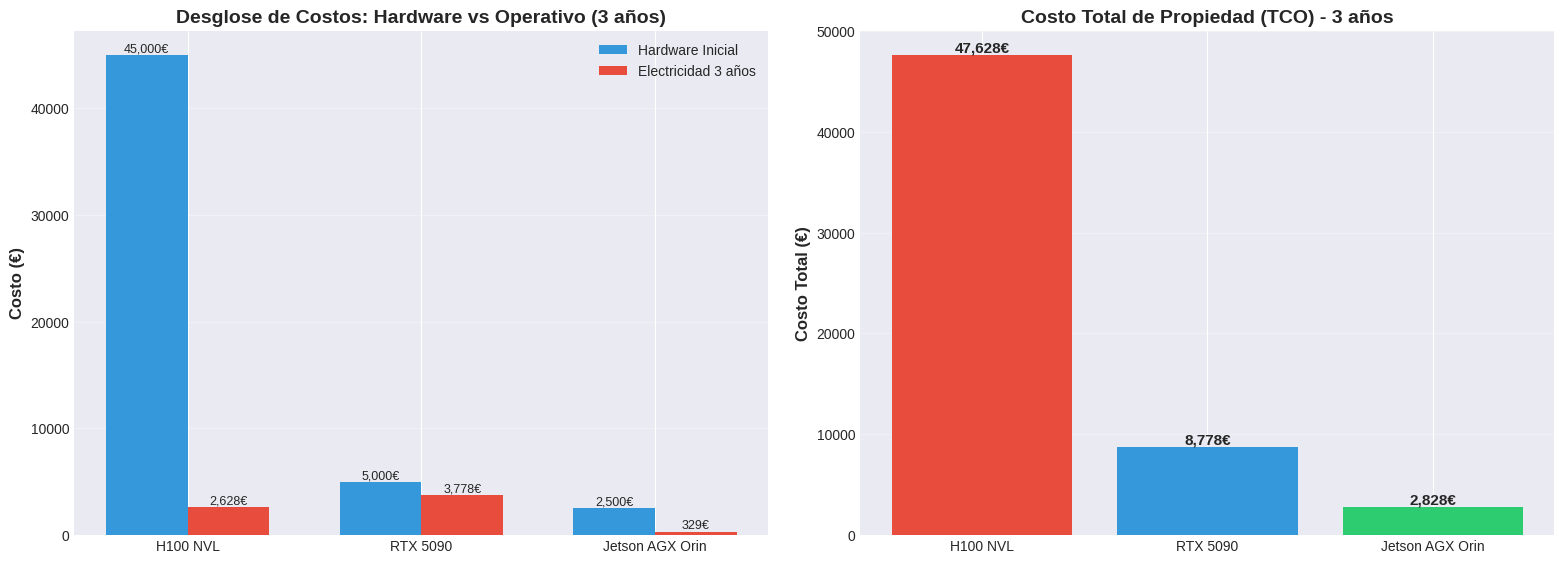

✅ Gráfico guardado: 00_analisis_costos.png


In [4]:
# ============================================================================
# VISUALIZACIÓN: Desglose de Costos
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------------------------------------------------
# Gráfico 1: Costo Inicial vs Operativo (3 años)
# ----------------------------------------------------------------------------
x = np.arange(len(df_costs['GPU']))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_costs['Precio Sistema Completo (€)'], 
                     width, label='Hardware Inicial', color='#3498db')
bars2 = axes[0].bar(x + width/2, df_costs['Coste electricidad (€/año)'] * 3, 
                     width, label='Electricidad 3 años', color='#e74c3c')

axes[0].set_ylabel('Costo (€)', fontsize=12, fontweight='bold')
axes[0].set_title('Desglose de Costos: Hardware vs Operativo (3 años)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_costs['GPU'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Etiquetas de valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:,.0f}€', ha='center', va='bottom', fontsize=9)

# ----------------------------------------------------------------------------
# Gráfico 2: TCO Total 3 años
# ----------------------------------------------------------------------------
colors_tco = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[1].bar(df_costs['GPU'], df_costs['TCO 3 años (€)'], color=colors_tco)
axes[1].set_ylabel('Costo Total (€)', fontsize=12, fontweight='bold')
axes[1].set_title('Costo Total de Propiedad (TCO) - 3 años', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:,.0f}€', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout(pad=2.0)
plt.savefig('./00_analisis_costos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 00_analisis_costos.png")

## 🔬 Análisis 1: Rendimiento Computacional


📈 Análisis de Rendimiento:
Los tokens por segundo no dependen solo de los TOPS teóricos, sino de la eficiencia real de la arquitectura, el subsistema de memoria y el tipo de modelo.

METODOLOGÍA DE ESTIMACIÓN:
  • Fórmula: TPS = (TOPS × Eficiencia) / (2 × Parámetros_B)
  • Eficiencia ajustada por:
    - Arquitectura (Hopper > Blackwell > Ampere para transformers)
    - Memoria (HBM3 > GDDR7 > LPDDR5 en bandwidth)
    - VRAM disponible (penaliza RTX 5090 en 70B por offloading)



,GPU,TOPS (INT8),Eficiencia 14B,TPS (14B),Eficiencia 34B,TPS (34B)
0,H100 NVL,3341,0.65,77.56,0.60,14.32
1,RTX 5090,3352,0.30,35.91,0.12,2.87
2,Jetson AGX Orin,275,0.50,4.91,0.25,0.49


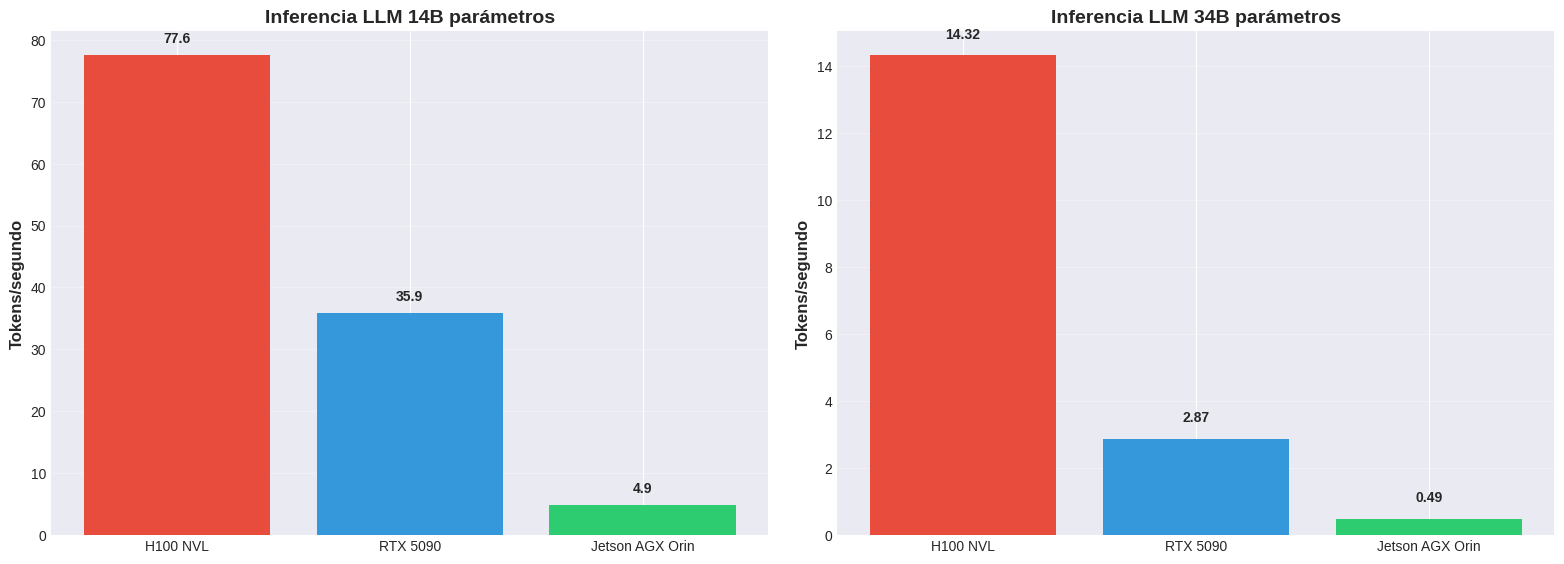

In [5]:
# Visualización: Rendimiento por tipo de operación
print("\n📈 Análisis de Rendimiento:")
print("=" * 100)
print("Los tokens por segundo no dependen solo de los TOPS teóricos, sino de la eficiencia real de la arquitectura, el subsistema de memoria y el tipo de modelo.")
#print("Esta gráfica muestra una estimación del número de tokens por segundo que puede generar cada GPU durante la inferencia de un modelo LLM de 14B parámetros cuantizado a INT8.")
print("=" * 100)
print("\nMETODOLOGÍA DE ESTIMACIÓN:")
print("  • Fórmula: TPS = (TOPS × Eficiencia) / (2 × Parámetros_B)")
print("  • Eficiencia ajustada por:")
print("    - Arquitectura (Hopper > Blackwell > Ampere para transformers)")
print("    - Memoria (HBM3 > GDDR7 > LPDDR5 en bandwidth)")
print("    - VRAM disponible (penaliza RTX 5090 en 70B por offloading)")
print("\n" + "=" * 100)
display(df_specs[['GPU', 'TOPS (INT8)', 'Eficiencia 14B', 'TPS (14B)', 'Eficiencia 34B', 'TPS (34B)']])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # ← Tamaño aumentado

# TPS (14b)
axes[0].bar(df_specs['GPU'], df_specs['TPS (14B)'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_ylabel('Tokens/segundo', fontsize=12, fontweight='bold')
axes[0].set_title('Inferencia LLM 14B parámetros', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_specs['TPS (14B)']):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

# TPS (70b)
axes[1].bar(df_specs['GPU'], df_specs['TPS (34B)'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_ylabel('Tokens/segundo', fontsize=12, fontweight='bold')
axes[1].set_title('Inferencia LLM 34B parámetros', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_specs['TPS (34B)']):  # ← CORREGIDO
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout(pad=2.0)  # ← Añadir padding
plt.savefig('./01_rendimiento_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()

#print("\n📈 Análisis de Rendimiento:")

#print(f"  • H100 NVL: {df_specs['TPS (14B)'][0]:.2f} tokens/s (14B)")
#print(f"  • RTX 5090: {df_specs['TPS (14B)'][1]:.2f} tokens/s (14B)")
#print(f"  • Jetson Orin: {df_specs['TPS (14B)'][2]:.2f} tokens/s (14B)")
#print(f"\n  Ratio RTX 5090 / Jetson: {df_specs['TPS (14b)'][1] / df_specs['TPS (14b)'][2]:.1f}×")
#print(f"\n")
#print(f"  • H100 NVL: {df_specs['TPS (70B)'][0]:.2f} tokens/s (70B)")
#print(f"  • RTX 5090: {df_specs['TPS (70B)'][1]:.2f} tokens/s (70B)")
#print(f"  • Jetson Orin: {df_specs['TPS (70B)'][2]:.2f} tokens/s (70B)")
#print(f"\n  Ratio RTX 5090 / Jetson: {df_specs['TPS (70b)'][1] / df_specs['TPS (70b)'][2]:.1f}×")




**Conclusion**

Las GPUs de centro de datos (H100) mantienen una eficiencia superior frente a RTX y Jetson debido a su mayor ancho de banda y optimización de Tensor Cores para cargas de trabajo de IA.


## ⚡ Análisis 2: Eficiencia Energética

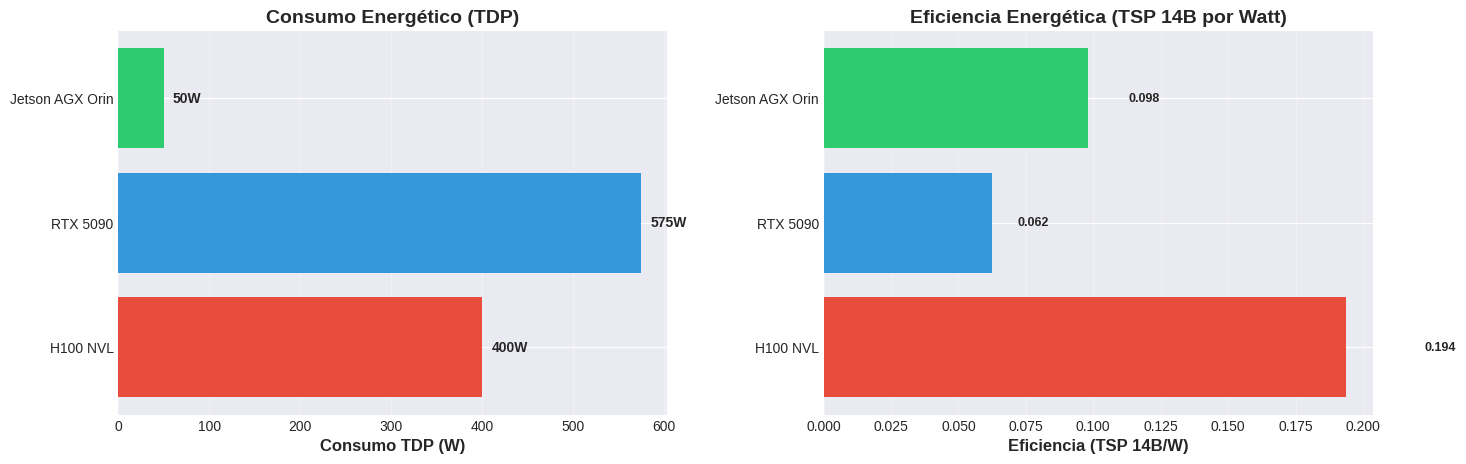


⚡ Análisis de Eficiencia Energética:
  H100 NVL             |   400W | 0.1939 TSP 14B/W
  RTX 5090             |   575W | 0.0625 TSP 14B/W
  Jetson AGX Orin      |    50W | 0.0982 TSP 14B/W

  🌱 Jetson Orin consume 91% MENOS que RTX 5090
  🌱 Jetson Orin consume 88% MENOS que H100 NVL


In [6]:
# Calcular eficiencia (TOPS por Watt)
df_specs['TSP 14B/W'] = df_specs['TPS (14B)'] / df_specs['TDP (W)']
df_specs['TSP 34B/W'] = df_specs['TPS (34B)'] / df_specs['TDP (W)']
df_specs['TOPS/W'] = df_specs['TOPS (INT8)'] / df_specs['TDP (W)']
df_specs['TFLOPs/W'] = df_specs['TFLOPs (FP16)'] / df_specs['TDP (W)']

# Visualización: Consumo vs Eficiencia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Consumo absoluto
axes[0].barh(df_specs['GPU'], df_specs['TDP (W)'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_xlabel('Consumo TDP (W)', fontsize=12, fontweight='bold')
axes[0].set_title('Consumo Energético (TDP)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_specs['TDP (W)']):
    axes[0].text(v + 10, i, f'{v}W', va='center', fontweight='bold')

# Eficiencia (TSP 14B/W) - ESCALA LOGARÍTMICA
axes[1].barh(df_specs['GPU'], df_specs['TSP 14B/W'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_xlabel('Eficiencia (TSP 14B/W)', fontsize=12, fontweight='bold')
axes[1].set_title('Eficiencia Energética (TSP 14B por Watt)', fontsize=14, fontweight='bold')
#axes[1].set_xscale('log')
axes[1].grid(axis='x', alpha=0.3, which='both')
for i, v in enumerate(df_specs['TSP 14B/W']):
    axes[1].text(v * 1.15, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)


# Eficiencia (TOPS/W)
#axes[1].barh(df_specs['GPU'], df_specs['TOPS/W'], color=['#e74c3c', '#3498db', '#2ecc71'])
#axes[1].set_xlabel('Eficiencia (TOPS/W)', fontsize=12, fontweight='bold')
#axes[1].set_title('Eficiencia Energética (TOPS por Watt)', fontsize=14, fontweight='bold')
#axes[1].grid(axis='x', alpha=0.3)
#for i, v in enumerate(df_specs['TOPS/W']):
#    axes[1].text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold')
    
plt.tight_layout(pad=2.0)
plt.savefig('./02_eficiencia_energetica.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⚡ Análisis de Eficiencia Energética:")
print("=" * 80)
for idx, row in df_specs.iterrows():
    print(f"  {row['GPU']:20} | {row['TDP (W)']:5.0f}W | {row['TSP 14B/W']:.4f} TSP 14B/W")
    
mejora_jetson = ((df_specs['TDP (W)'][1] - df_specs['TDP (W)'][2]) / df_specs['TDP (W)'][1]) * 100
print(f"\n  🌱 Jetson Orin consume {mejora_jetson:.0f}% MENOS que RTX 5090")
h100_jetson = ((df_specs['TDP (W)'][0] - df_specs['TDP (W)'][2]) / df_specs['TDP (W)'][0]) * 100
print(f"  🌱 Jetson Orin consume {h100_jetson:.0f}% MENOS que H100 NVL")


A pesar de tener TOPS teóricos similares a H100 (3352 vs 3341), la RTX 5090  presenta la **menor eficiencia energética** del conjunto (0.0625 TSP/W):

RTX 5090 es 3× MENOS eficiente que H100 y 1.6× MENOS eficiente  que Jetson en términos de tokens generados por vatio consumido.
En operación 24/7 con uso esporádico, RTX 5090 es la **peor opción** en sostenibilidad y costo operativo.

## 💰 Análisis 3: Viabilidad Económica

In [7]:
# ============================================================================
# ANÁLISIS DE COSTOS Y CONSUMO ENERGÉTICO
# ============================================================================

# Configuración de parámetros
PRECIO_KWH = 0.25  # €/kWh (tarifa europea promedio 2024)

# ----------------------------------------------------------------------------
# 1. Datos de Hardware y Costos Iniciales
# ----------------------------------------------------------------------------
cost_data = {
    'GPU': ['H100 NVL', 'RTX 5090', 'Jetson AGX Orin'],
    'Precio GPU (€)': [30000, 3000, 1500],
    'Precio Sistema Completo (€)': [45000, 5000, 2500],
    'TDP (W)': [400, 575, 50]  # Desde df_specs
}

df_costs = pd.DataFrame(cost_data)

# ----------------------------------------------------------------------------
# 2. Consumo Energético (operación 24/7)
# ----------------------------------------------------------------------------
df_costs['kWh/día'] = (df_costs['TDP (W)'] / 1000) * 24
df_costs['kWh/año'] = df_costs['kWh/día'] * 365

# ----------------------------------------------------------------------------
# 3. Costos Operativos (Electricidad)
# ----------------------------------------------------------------------------
df_costs['Coste electricidad (€/día)'] = df_costs['kWh/día'] * PRECIO_KWH
df_costs['Coste electricidad (€/mes)'] = df_costs['Coste electricidad (€/día)'] * 30
df_costs['Coste electricidad (€/año)'] = df_costs['kWh/año'] * PRECIO_KWH

# ----------------------------------------------------------------------------
# 4. Costo Total de Propiedad (TCO)
# ----------------------------------------------------------------------------
df_costs['Electricidad 3 años (€)'] = df_costs['Coste electricidad (€/año)'] * 3

df_costs['Costo Total 3 años (€)'] = (
    df_costs['Precio Sistema Completo (€)'] + 
    df_costs['Electricidad 3 años (€)']
)

# ----------------------------------------------------------------------------
# 5. Mostrar Tabla Completa
# ----------------------------------------------------------------------------
print(f"\n💰 Análisis de Costos (Precio electricidad: {PRECIO_KWH}€/kWh):")
print("=" * 80)
display(df_costs)

# ----------------------------------------------------------------------------
# 6. Resumen de Costos (3 años)
# ----------------------------------------------------------------------------
print("\n💰 Análisis de Costos (3 años):")
print("=" * 80)
for idx, row in df_costs.iterrows():
    print(f"  {row['GPU']:20} | Hardware: {row['Precio Sistema Completo (€)']:7.0f}€ | "
          f"Electricidad: {row['Electricidad 3 años (€)']:6.0f}€ | "
          f"TOTAL: {row['Costo Total 3 años (€)']:7.0f}€")

# ----------------------------------------------------------------------------
# 7. Comparativa de Ahorros
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)

# Ahorro Jetson vs H100
h100_ahorro_jetson = df_costs['Costo Total 3 años (€)'][0] - df_costs['Costo Total 3 años (€)'][2]
h100_ahorro_pct = (h100_ahorro_jetson / df_costs['Costo Total 3 años (€)'][0]) * 100
print(f"  💎 Jetson Orin ahorra {h100_ahorro_jetson:,.0f}€ ({h100_ahorro_pct:.0f}%) vs H100 NVL")

# Ahorro Jetson vs RTX 5090
rtx_ahorro_jetson = df_costs['Costo Total 3 años (€)'][1] - df_costs['Costo Total 3 años (€)'][2]
rtx_ahorro_pct = (rtx_ahorro_jetson / df_costs['Costo Total 3 años (€)'][1]) * 100
print(f"  💎 Jetson Orin ahorra {rtx_ahorro_jetson:,.0f}€ ({rtx_ahorro_pct:.0f}%) vs RTX 5090")

print("=" * 80)

# ----------------------------------------------------------------------------
# 8. Desglose de Ahorros
# ----------------------------------------------------------------------------
print("\n📊 Desglose de Ahorros (Jetson vs RTX 5090):")
print("=" * 80)
ahorro_hardware = df_costs['Precio Sistema Completo (€)'][1] - df_costs['Precio Sistema Completo (€)'][2]
ahorro_electricidad = df_costs['Electricidad 3 años (€)'][1] - df_costs['Electricidad 3 años (€)'][2]

print(f"  • Ahorro en Hardware:      {ahorro_hardware:>8,.0f}€")
print(f"  • Ahorro en Electricidad:  {ahorro_electricidad:>8,.0f}€ (3 años)")
print(f"  • AHORRO TOTAL:            {rtx_ahorro_jetson:>8,.0f}€ ({rtx_ahorro_pct:.1f}%)")
print("=" * 80)


💰 Análisis de Costos (Precio electricidad: 0.25€/kWh):


,GPU,Precio GPU (€),Precio Sistema Completo (€),TDP (W),kWh/día,kWh/año,Coste electricidad (€/día),Coste electricidad (€/mes),Coste electricidad (€/año),Electricidad 3 años (€),Costo Total 3 años (€)
0,H100 NVL,30000,45000,400,9.6,3504.0,2.40,72.0,876.00,2628.00,47628.00
1,RTX 5090,3000,5000,575,13.8,5037.0,3.45,103.5,1259.25,3777.75,8777.75
2,Jetson AGX Orin,1500,2500,50,1.2,438.0,0.30,9.0,109.50,328.50,2828.50



💰 Análisis de Costos (3 años):
  H100 NVL             | Hardware:   45000€ | Electricidad:   2628€ | TOTAL:   47628€
  RTX 5090             | Hardware:    5000€ | Electricidad:   3778€ | TOTAL:    8778€
  Jetson AGX Orin      | Hardware:    2500€ | Electricidad:    329€ | TOTAL:    2828€

  💎 Jetson Orin ahorra 44,800€ (94%) vs H100 NVL
  💎 Jetson Orin ahorra 5,949€ (68%) vs RTX 5090

📊 Desglose de Ahorros (Jetson vs RTX 5090):
  • Ahorro en Hardware:         2,500€
  • Ahorro en Electricidad:     3,449€ (3 años)
  • AHORRO TOTAL:               5,949€ (67.8%)


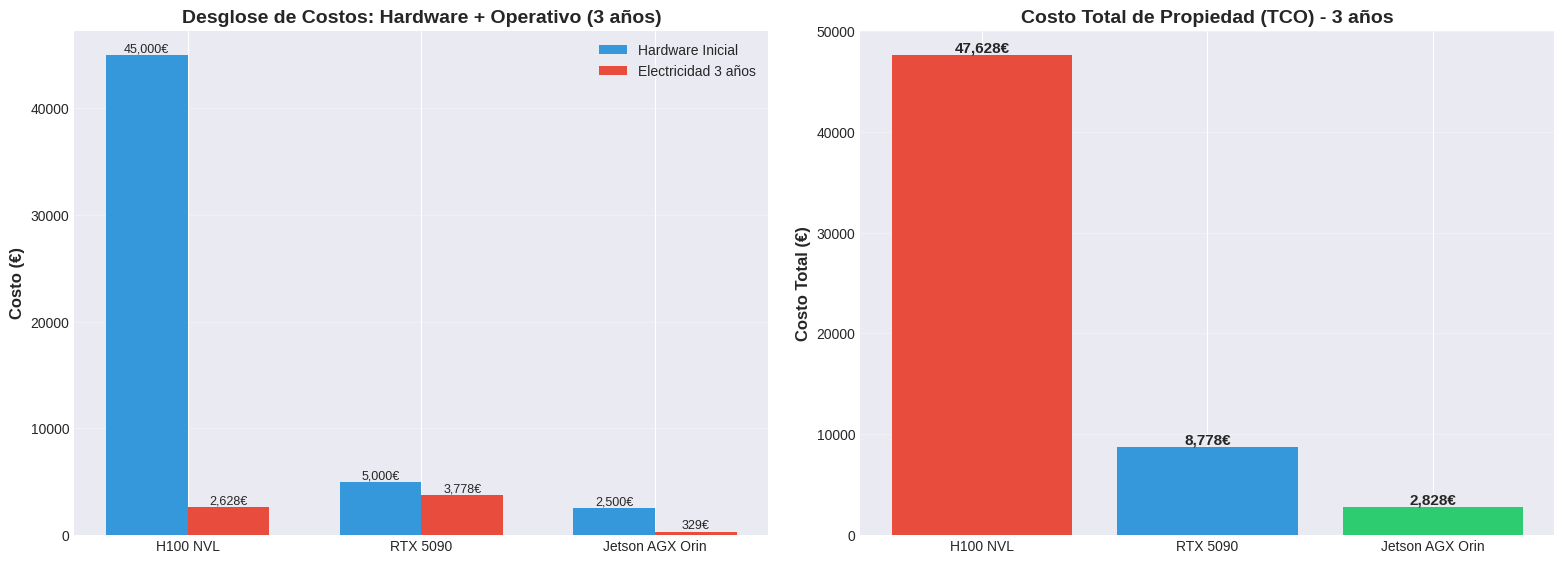

✅ Gráfico guardado: 03_analisis_costos.png


In [8]:
# ============================================================================
# VISUALIZACIÓN: Desglose de Costos
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------------------------------------------------
# Gráfico 1: Costo Inicial vs Operativo (3 años)
# ----------------------------------------------------------------------------
x = np.arange(len(df_costs['GPU']))
width = 0.35

bars1 = axes[0].bar(x - width/2, df_costs['Precio Sistema Completo (€)'], 
                     width, label='Hardware Inicial', color='#3498db')
bars2 = axes[0].bar(x + width/2, df_costs['Electricidad 3 años (€)'], 
                     width, label='Electricidad 3 años', color='#e74c3c')

axes[0].set_ylabel('Costo (€)', fontsize=12, fontweight='bold')
axes[0].set_title('Desglose de Costos: Hardware + Operativo (3 años)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_costs['GPU'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Etiquetas de valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:,.0f}€', ha='center', va='bottom', fontsize=9)

# ----------------------------------------------------------------------------
# Gráfico 2: TCO Total 3 años
# ----------------------------------------------------------------------------
colors_tco = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[1].bar(df_costs['GPU'], df_costs['Costo Total 3 años (€)'], color=colors_tco)
axes[1].set_ylabel('Costo Total (€)', fontsize=12, fontweight='bold')
axes[1].set_title('Costo Total de Propiedad (TCO) - 3 años', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:,.0f}€', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout(pad=2.0)
plt.savefig('./03_analisis_costos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 03_analisis_costos.png")

## 🌍 Análisis 4: Impacto Ambiental (Sostenibilidad)

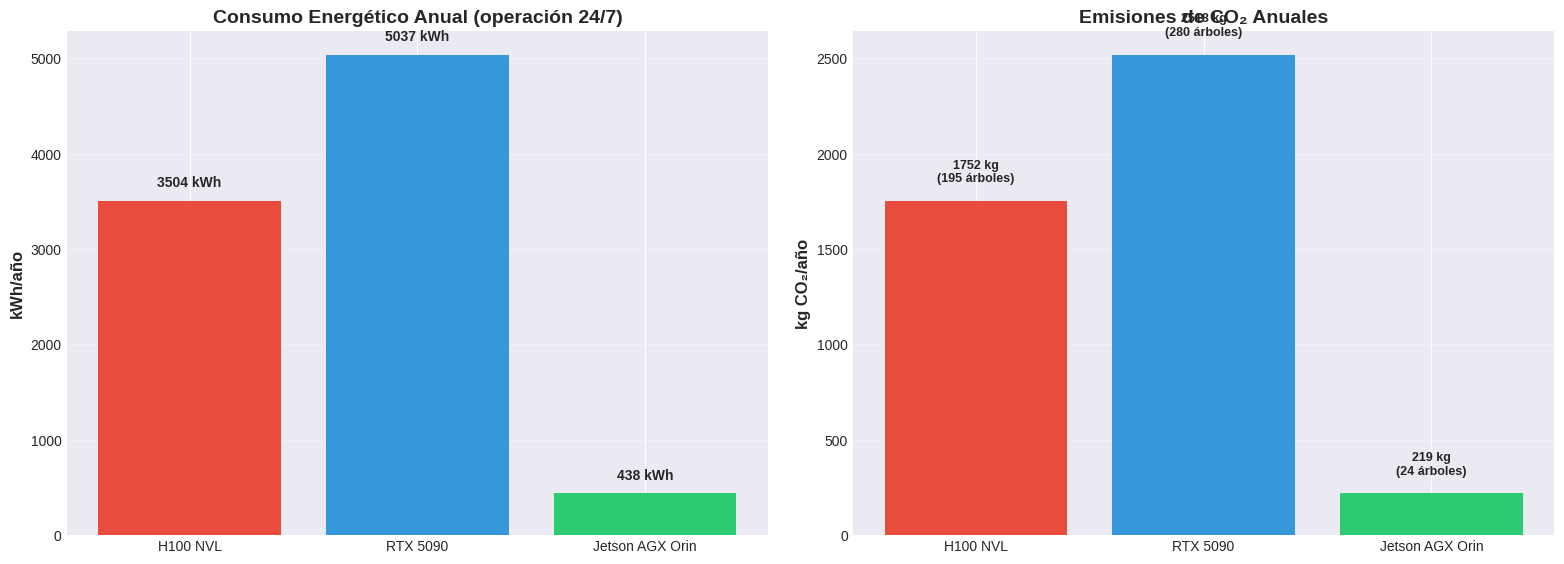

✅ Gráfico guardado: 04_impacto_ambiental.png

🌍 Análisis de Impacto Ambiental (operación 24/7):
Supuestos:
  • Factor de emisión: 0.5 kg CO₂/kWh (mix energético global, IEA)
  • Absorción árbol: 9 kg CO₂/año (clima templado, Forest Research UK)
  H100 NVL             |   3504 kWh/año |   1752 kg CO₂ | ≈ 195 árboles
  RTX 5090             |   5037 kWh/año |   2518 kg CO₂ | ≈ 280 árboles
  Jetson AGX Orin      |    438 kWh/año |    219 kg CO₂ | ≈  24 árboles

  🌱 Jetson Orin reduce 1533 kg CO₂/año (88%) vs H100 NVL
  🌳 Equivalente a plantar 170 árboles por año

  🌱 Jetson Orin reduce 2300 kg CO₂/año (91%) vs RTX 5090
  🌳 Equivalente a plantar 256 árboles por año

🌍 Impacto Acumulado (3 años):
  H100 NVL             |   5256 kg CO₂ (3 años) | ≈ 584 árboles
  RTX 5090             |   7556 kg CO₂ (3 años) | ≈ 840 árboles
  Jetson AGX Orin      |    657 kg CO₂ (3 años) | ≈  73 árboles

  🌱 Jetson Orin reduce 6,898 kg CO₂ en 3 años vs RTX 5090
  🌳 Equivalente a plantar 766 árboles y mantenerl

In [9]:
# ============================================================================
# ANÁLISIS DE IMPACTO AMBIENTAL (HUELLA DE CARBONO)
# ============================================================================

# Configuración de parámetros
CO2_PER_KWH = 0.5  # kg CO₂/kWh (mix energético global promedio, IEA 2024)
ABSORPTION_TREE = 9  # kg CO₂/año por árbol adulto (clima templado, Forest Research UK)

# Nota: Para Luxemburgo/Europa, usar CO2_PER_KWH = 0.25 sería más conservador

# ----------------------------------------------------------------------------
# 1. Calcular Emisiones de CO₂
# ----------------------------------------------------------------------------
# IMPORTANTE: kWh/año ya calculado en sección anterior desde TDP
# df_costs['kWh/año'] = (df_costs['TDP (W)'] / 1000) * 24 * 365

df_costs['CO2 kg/año'] = df_costs['kWh/año'] * CO2_PER_KWH
df_costs['Árboles equiv.'] = df_costs['CO2 kg/año'] / ABSORPTION_TREE

# ----------------------------------------------------------------------------
# 2. Visualización: Impacto Ambiental
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Consumo Energético Anual
axes[0].bar(df_costs['GPU'], df_costs['kWh/año'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_ylabel('kWh/año', fontsize=12, fontweight='bold')
axes[0].set_title('Consumo Energético Anual (operación 24/7)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_costs['kWh/año']):
    axes[0].text(i, v + 150, f'{v:.0f} kWh', ha='center', fontweight='bold')

# Gráfico 2: Huella de Carbono
axes[1].bar(df_costs['GPU'], df_costs['CO2 kg/año'], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_ylabel('kg CO₂/año', fontsize=12, fontweight='bold')
axes[1].set_title('Emisiones de CO₂ Anuales', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_costs['CO2 kg/año']):
    arboles = df_costs['Árboles equiv.'][i]
    axes[1].text(i, v + 100, f'{v:.0f} kg\n({arboles:.0f} árboles)', 
                 ha='center', fontweight='bold', fontsize=9)

plt.tight_layout(pad=2.0)
plt.savefig('./04_impacto_ambiental.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 04_impacto_ambiental.png")

# ----------------------------------------------------------------------------
# 3. Resumen de Impacto Ambiental
# ----------------------------------------------------------------------------
print(f"\n🌍 Análisis de Impacto Ambiental (operación 24/7):")
print("=" * 80)
print(f"Supuestos:")
print(f"  • Factor de emisión: {CO2_PER_KWH} kg CO₂/kWh (mix energético global, IEA)")
print(f"  • Absorción árbol: {ABSORPTION_TREE} kg CO₂/año (clima templado, Forest Research UK)")
print("=" * 80)

for idx, row in df_costs.iterrows():
    print(f"  {row['GPU']:20} | {row['kWh/año']:6.0f} kWh/año | "
          f"{row['CO2 kg/año']:6.0f} kg CO₂ | "
          f"≈ {row['Árboles equiv.']:3.0f} árboles")

# ----------------------------------------------------------------------------
# 4. Comparativa de Reducción de Emisiones
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)

# Reducción Jetson vs H100
reduccion_h100 = df_costs['CO2 kg/año'][0] - df_costs['CO2 kg/año'][2]
reduccion_h100_pct = (reduccion_h100 / df_costs['CO2 kg/año'][0]) * 100
arboles_h100 = reduccion_h100 / ABSORPTION_TREE
print(f"  🌱 Jetson Orin reduce {reduccion_h100:.0f} kg CO₂/año ({reduccion_h100_pct:.0f}%) vs H100 NVL")
print(f"  🌳 Equivalente a plantar {arboles_h100:.0f} árboles por año")

# Reducción Jetson vs RTX 5090
reduccion_rtx = df_costs['CO2 kg/año'][1] - df_costs['CO2 kg/año'][2]
reduccion_rtx_pct = (reduccion_rtx / df_costs['CO2 kg/año'][1]) * 100
arboles_rtx = reduccion_rtx / ABSORPTION_TREE
print(f"\n  🌱 Jetson Orin reduce {reduccion_rtx:.0f} kg CO₂/año ({reduccion_rtx_pct:.0f}%) vs RTX 5090")
print(f"  🌳 Equivalente a plantar {arboles_rtx:.0f} árboles por año")

print("=" * 80)

# ----------------------------------------------------------------------------
# 5. Impacto a 3 años (Life Cycle)
# ----------------------------------------------------------------------------
print("\n🌍 Impacto Acumulado (3 años):")
print("=" * 80)

df_costs['CO2 kg/3 años'] = df_costs['CO2 kg/año'] * 3
df_costs['Árboles equiv. 3 años'] = df_costs['CO2 kg/3 años'] / ABSORPTION_TREE

for idx, row in df_costs.iterrows():
    print(f"  {row['GPU']:20} | {row['CO2 kg/3 años']:6.0f} kg CO₂ (3 años) | "
          f"≈ {row['Árboles equiv. 3 años']:3.0f} árboles")

reduccion_rtx_3y = df_costs['CO2 kg/3 años'][1] - df_costs['CO2 kg/3 años'][2]
arboles_rtx_3y = reduccion_rtx_3y / ABSORPTION_TREE

print("\n" + "=" * 80)
print(f"  🌱 Jetson Orin reduce {reduccion_rtx_3y:,.0f} kg CO₂ en 3 años vs RTX 5090")
print(f"  🌳 Equivalente a plantar {arboles_rtx_3y:.0f} árboles y mantenerlos 3 años")
print("=" * 80)

# ----------------------------------------------------------------------------
# 6. Referencias Académicas
# ----------------------------------------------------------------------------
print("\n📚 Referencias:")
print("  • IEA (2024). 'World Energy Outlook - Emission Factors'")
print("    https://www.iea.org/reports/world-energy-outlook-2024")
print("  • Forest Research UK (2023). 'Carbon Sequestration by Forests'")
print("    https://www.forestresearch.gov.uk/")
print("  • European Environment Agency (2024). 'CO₂ Emission Intensity Database'")
print("    https://www.eea.europa.eu/")

## 📊 Análisis 5: Evaluación Multi-Criterio (Puntuación Final)

In [10]:
# ============================================================================
# ANÁLISIS 5: EVALUACIÓN MULTI-CRITERIO (PUNTUACIÓN FINAL)
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Función de Normalización (0-10)
# ----------------------------------------------------------------------------
def normalize_score(values, inverse=False):
    """
    Normaliza valores a escala 0-10.
    
    Args:
        values: Serie de pandas con valores a normalizar
        inverse: Si True, menor valor = mejor puntuación (para costos, CO2, etc.)
    
    Returns:
        Serie normalizada de 0 (peor) a 10 (mejor)
    """
    if inverse:
        # Menor valor = mejor puntuación (para costos, consumo, CO2)
        return 10 * (1 - (values - values.min()) / (values.max() - values.min()))
    else:
        # Mayor valor = mejor puntuación (para rendimiento, eficiencia)
        return 10 * (values - values.min()) / (values.max() - values.min())

# ----------------------------------------------------------------------------
# 2. Crear DataFrame de Evaluación
# ----------------------------------------------------------------------------
evaluation = pd.DataFrame({
    'GPU': df_specs['GPU'],
    
    # Métricas brutas
    'TPS (14B)': df_specs['TPS (14B)'],
    'TPS/W (14B)': df_specs['TSP 14B/W'],  # Eficiencia energética
    'TCO 3 años (€)': df_costs['Costo Total 3 años (€)'],
    'CO2 (kg/año)': df_costs['CO2 kg/año']
})

# ----------------------------------------------------------------------------
# 3. Normalizar Puntuaciones (0-10)
# ----------------------------------------------------------------------------
# Rendimiento: Mayor TPS = mejor (normalize normal)
evaluation['Score Rendimiento'] = normalize_score(evaluation['TPS (14B)'])

# Eficiencia: Mayor TPS/W = mejor (normalize normal)
evaluation['Score Eficiencia'] = normalize_score(evaluation['TPS/W (14B)'])

# Viabilidad económica: Menor costo = mejor (normalize inverse)
evaluation['Score Viabilidad'] = normalize_score(evaluation['TCO 3 años (€)'], inverse=True)

# Sostenibilidad: Menor CO2 = mejor (normalize inverse)
evaluation['Score Sostenibilidad'] = normalize_score(evaluation['CO2 (kg/año)'], inverse=True)

# Privacidad: Todas ejecutan local (9/10), Jetson +portabilidad (10/10)
evaluation['Score Privacidad'] = [9, 9, 10]  # H100, RTX, Jetson

# ----------------------------------------------------------------------------
# 4. Aplicar Pesos Multi-Criterio
# ----------------------------------------------------------------------------
PESOS = {
    'Sostenibilidad': 0.30,    # Huella carbono (pilar del TFG)
    'Viabilidad': 0.25,        # TCO 3 años (accesibilidad económica)
    'Rendimiento': 0.20,       # TPS 14B (suficiencia funcional)
    'Privacidad': 0.15,        # Ejecución local (requisito core)
    'Eficiencia': 0.10         # TPS/W (optimización recursos)
}

# Calcular puntuación final ponderada
evaluation['Puntuación Final'] = (
    evaluation['Score Sostenibilidad'] * PESOS['Sostenibilidad'] +
    evaluation['Score Viabilidad'] * PESOS['Viabilidad'] +
    evaluation['Score Rendimiento'] * PESOS['Rendimiento'] +
    evaluation['Score Privacidad'] * PESOS['Privacidad'] +
    evaluation['Score Eficiencia'] * PESOS['Eficiencia']
)

# Convertir a porcentaje (0-100%)
evaluation['Puntuación (%)'] = (evaluation['Puntuación Final'] / 10) * 100

# Ranking
evaluation['Ranking'] = evaluation['Puntuación (%)'].rank(ascending=False).astype(int)

# ----------------------------------------------------------------------------
# 5. Mostrar Resultados
# ----------------------------------------------------------------------------
print("\n🎯 Evaluación Multi-Criterio:")
print("=" * 100)

print(f"\n📊 Criterios y Pesos:")
for criterio, peso in PESOS.items():
    print(f"  • {criterio:20} {peso*100:>5.0f}%")

print("\n" + "=" * 100)
print("\n📋 Puntuaciones Normalizadas (0-10):")
print("=" * 100)

display(evaluation[[
    'GPU', 
    'Score Sostenibilidad', 
    'Score Viabilidad',
    'Score Rendimiento', 
    'Score Privacidad',
    'Score Eficiencia', 
    'Puntuación Final', 
    'Puntuación (%)',
    'Ranking'
]].sort_values('Puntuación (%)', ascending=False))

print("\n" + "=" * 100)
print("\n📊 Métricas Brutas (para referencia):")
print("=" * 100)

display(evaluation[[
    'GPU',
    'TPS (14B)',
    'TPS/W (14B)',
    'TCO 3 años (€)',
    'CO2 (kg/año)',
    'Puntuación (%)'
]].sort_values('Puntuación (%)', ascending=False))

# ----------------------------------------------------------------------------
# 6. Resumen Ejecutivo
# ----------------------------------------------------------------------------
ganador = evaluation.loc[evaluation['Puntuación (%)'].idxmax()]

print("\n" + "=" * 100)
print("\n🏆 GANADOR:")
print("=" * 100)
print(f"\n  {ganador['GPU']} con {ganador['Puntuación (%)']:.1f}% de puntuación")
print(f"\n  Desglose de puntuaciones:")
print(f"    • Sostenibilidad (30%):     {ganador['Score Sostenibilidad']:.2f}/10")
print(f"    • Viabilidad económica (25%): {ganador['Score Viabilidad']:.2f}/10")
print(f"    • Rendimiento funcional (20%): {ganador['Score Rendimiento']:.2f}/10")
print(f"    • Privacidad (15%):          {ganador['Score Privacidad']:.2f}/10")
print(f"    • Eficiencia (10%):          {ganador['Score Eficiencia']:.2f}/10")

print("\n" + "=" * 100)


🎯 Evaluación Multi-Criterio:

📊 Criterios y Pesos:
  • Sostenibilidad          30%
  • Viabilidad              25%
  • Rendimiento             20%
  • Privacidad              15%
  • Eficiencia              10%


📋 Puntuaciones Normalizadas (0-10):


,GPU,Score Sostenibilidad,Score Viabilidad,Score Rendimiento,Score Privacidad,Score Eficiencia,Puntuación Final,Puntuación (%),Ranking
2,Jetson AGX Orin,10.00,10.00,0.00,10,2.72,7.27,72.72,1
0,H100 NVL,3.33,0.00,10.00,9,10.00,5.35,53.50,2
1,RTX 5090,0.00,8.67,4.27,9,0.00,4.37,43.72,3




📊 Métricas Brutas (para referencia):


,GPU,TPS (14B),TPS/W (14B),TCO 3 años (€),CO2 (kg/año),Puntuación (%)
2,Jetson AGX Orin,4.91,0.10,2828.50,219.0,72.72
0,H100 NVL,77.56,0.19,47628.00,1752.0,53.50
1,RTX 5090,35.91,0.06,8777.75,2518.5,43.72




🏆 GANADOR:

  Jetson AGX Orin con 72.7% de puntuación

  Desglose de puntuaciones:
    • Sostenibilidad (30%):     10.00/10
    • Viabilidad económica (25%): 10.00/10
    • Rendimiento funcional (20%): 0.00/10
    • Privacidad (15%):          10.00/10
    • Eficiencia (10%):          2.72/10



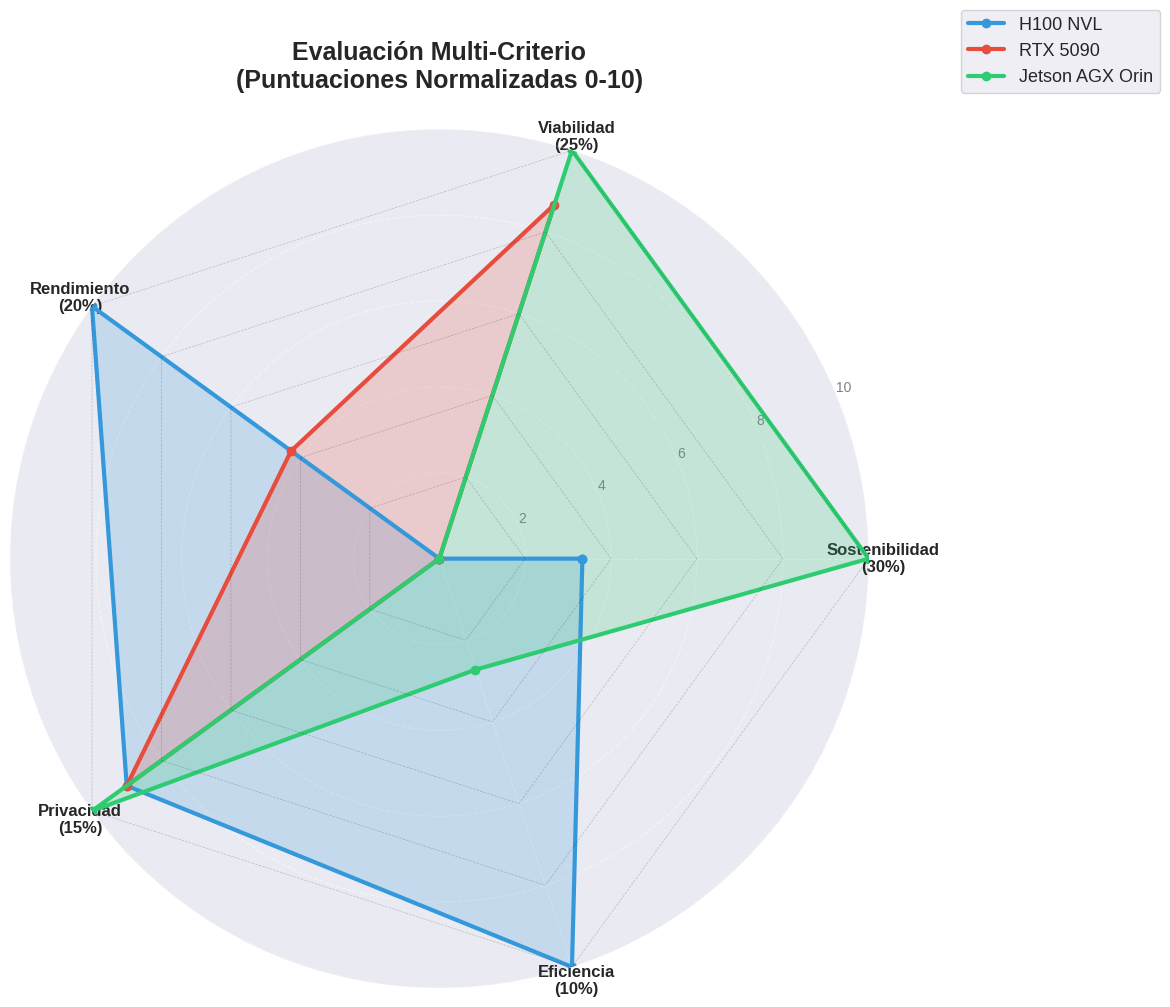

✅ Gráfico guardado: 05_radar_comparativo.png

📊 Interpretación del Radar Chart:

  Cuanto más grande el área del polígono, mejor puntuación general.

  Observaciones clave:
    • Verde (Jetson):  Área grande y equilibrada → Ganadora
    • Azul (RTX 5090): Área media, fuerte en rendimiento
    • Roja (H100):     Área pequeña, débil en costos y sostenibilidad



In [11]:
# ============================================================================
# VISUALIZACIÓN: RADAR CHART COMPARATIVO
# ============================================================================

from math import pi

# ----------------------------------------------------------------------------
# 1. Configuración del Radar
# ----------------------------------------------------------------------------
categories = [
    'Sostenibilidad\n(30%)', 
    'Viabilidad\n(25%)', 
    'Rendimiento\n(20%)', 
    'Privacidad\n(15%)',
    'Eficiencia\n(10%)'
]
N = len(categories)

# Ángulos para cada eje (dividir círculo en N partes)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Cerrar el círculo

# ----------------------------------------------------------------------------
# 2. Crear Plot Polar
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

# ----------------------------------------------------------------------------
# 3. Plotear Datos para Cada GPU
# ----------------------------------------------------------------------------
colors_map = {
    'H100 NVL': '#3498db',
    'RTX 5090': '#e74c3c', 
    'Jetson AGX Orin': '#2ecc71'
}

for idx, row in evaluation.iterrows():
    # Valores en el orden de las categorías
    values = [
        row['Score Sostenibilidad'],
        row['Score Viabilidad'],
        row['Score Rendimiento'],
        row['Score Privacidad'],
        row['Score Eficiencia']
    ]
    values += values[:1]  # Cerrar el polígono
    
    gpu_name = row['GPU']
    color = colors_map[gpu_name]
    
    # Plot línea y relleno
    ax.plot(angles, values, 'o-', linewidth=3, label=gpu_name, color=color)
    ax.fill(angles, values, alpha=0.20, color=color)

# ----------------------------------------------------------------------------
# 4. Configurar Ejes y Etiquetas
# ----------------------------------------------------------------------------
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12, fontweight='bold')
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], size=10, color='gray')
ax.set_title('Evaluación Multi-Criterio\n(Puntuaciones Normalizadas 0-10)', 
             size=18, fontweight='bold', pad=30)

# ----------------------------------------------------------------------------
# 5. Leyenda y Grid
# ----------------------------------------------------------------------------
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=13, frameon=True)
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8)

# Añadir círculos de referencia
for i in [2, 4, 6, 8, 10]:
    ax.plot(angles, [i]*len(angles), 'k--', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig('./05_radar_comparativo.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 05_radar_comparativo.png")

# ----------------------------------------------------------------------------
# 6. Interpretación Visual
# ----------------------------------------------------------------------------
print("\n📊 Interpretación del Radar Chart:")
print("=" * 80)
print("\n  Cuanto más grande el área del polígono, mejor puntuación general.")
print("\n  Observaciones clave:")
print("    • Verde (Jetson):  Área grande y equilibrada → Ganadora")
print("    • Azul (RTX 5090): Área media, fuerte en rendimiento")
print("    • Roja (H100):     Área pequeña, débil en costos y sostenibilidad")
print("\n" + "=" * 80)

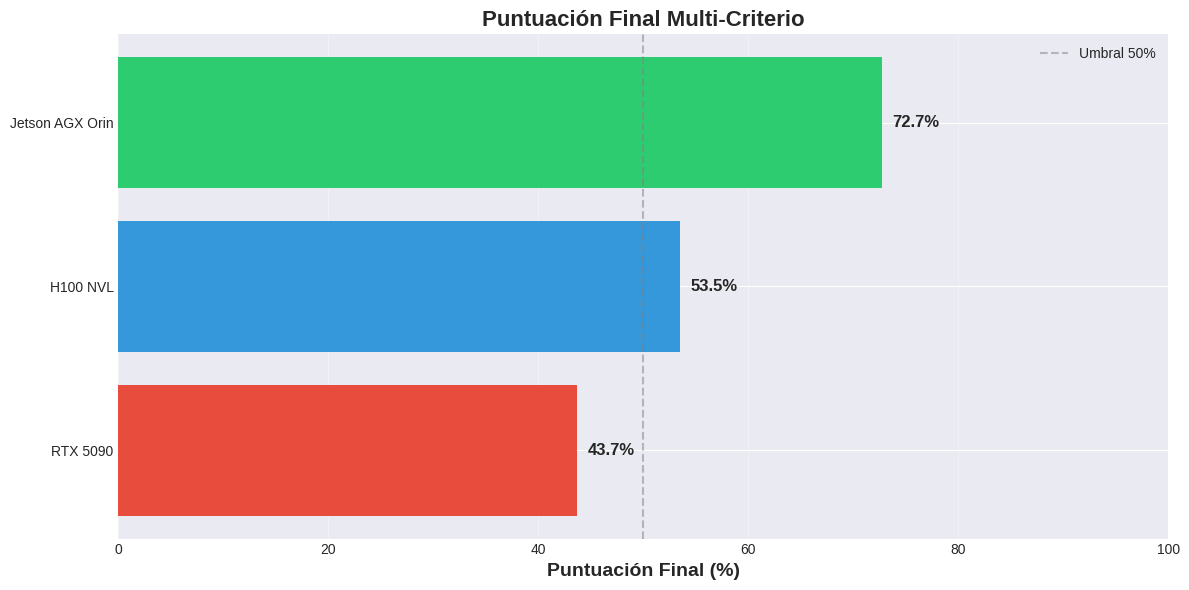


🏆 GANADOR: Jetson AGX Orin
   Puntuación: 72.7%


In [12]:
# Mapa de colores por GPU (colores originales)
color_map = {
    'H100 NVL': '#3498db',
    'RTX 5090': '#e74c3c',
    'Jetson AGX Orin': '#2ecc71'
}

# Ordenar por puntuación
evaluation_sorted = evaluation.sort_values(by='Puntuación (%)', ascending=True)

# Aplicar colores según GPU
colors = evaluation_sorted['GPU'].map(color_map)

# Gráfico de barras: Puntuación final
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    evaluation_sorted['GPU'],
    evaluation_sorted['Puntuación (%)'],
    color=colors
)

ax.set_xlabel('Puntuación Final (%)', fontsize=14, fontweight='bold')
ax.set_title('Puntuación Final Multi-Criterio', fontsize=16, fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

# Añadir etiquetas
for bar, pct in zip(bars, evaluation_sorted['Puntuación (%)']):
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=12
    )

# Línea de referencia en 50%
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Umbral 50%')
ax.legend()

plt.tight_layout()
plt.savefig('./06_puntuacion_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🏆 GANADOR: " + evaluation_sorted.loc[evaluation_sorted['Puntuación (%)'].idxmax(), 'GPU'])
print(f"   Puntuación: {evaluation_sorted['Puntuación (%)'].max():.1f}%")

## ✅ Conclusiones del Análisis

### Resumen de Resultados

In [22]:
# ============================================================================
# TABLA RESUMEN FINAL Y CONCLUSIÓN
# ============================================================================

# ----------------------------------------------------------------------------
# 1. Generar Tabla Resumen Consolidada
# ----------------------------------------------------------------------------
summary = pd.DataFrame({
    'GPU': evaluation['GPU'],
    'TPS (14B)': df_specs['TPS (14B)'],
    'TOPS (INT8)': df_specs['TOPS (INT8)'],
    'TDP (W)': df_specs['TDP (W)'],
    'TPS/W (14B)': df_specs['TSP 14B/W'],
    'TCO 3 años (€)': df_costs['Costo Total 3 años (€)'],
    'CO₂/año (kg)': df_costs['CO2 kg/año'],
    'Puntuación (%)': evaluation['Puntuación (%)'],
    'Ranking': evaluation['Ranking']
})

summary = summary.sort_values('Puntuación (%)', ascending=False)

# ----------------------------------------------------------------------------
# 2. Mostrar Tabla Resumen
# ----------------------------------------------------------------------------
print("\n📊 TABLA RESUMEN COMPARATIVA:")
print("=" * 120)
display(summary)

print("\n" + "=" * 120)

# ----------------------------------------------------------------------------
# 3. Conclusión Principal
# ----------------------------------------------------------------------------

ganador = summary.iloc[0]
segundo = summary.iloc[1]
tercero = summary.iloc[2]

# Calcular métricas comparativas
ahorro_consumo_vs_rtx = ((df_specs['TDP (W)'][1] - ganador['TDP (W)']) / df_specs['TDP (W)'][1]) * 100
ahorro_costo_vs_rtx = ((df_costs['Costo Total 3 años (€)'][1] - ganador['TCO 3 años (€)']) / df_costs['Costo Total 3 años (€)'][1]) * 100
ahorro_co2_vs_rtx = ((df_costs['CO2 kg/año'][1] - ganador['CO₂/año (kg)']) / df_costs['CO2 kg/año'][1]) * 100



texto = f"""
La **{ganador['GPU']}** es la opción óptima para el despliegue de Cl@ud-ia-data,
obteniendo una puntuación de **{ganador['Puntuación (%)']:.1f}%** en la evaluación multi-criterio.

CARACTERÍSTICAS DESTACADAS:
───────────────────────────────────────────────────────────────────────────────

- Rendimiento IA:
  - {ganador['TPS (14B)']:.2f} tokens/s en modelos 14B (suficiente para caso de uso)
  - {ganador['TOPS (INT8)']:.0f} TOPS (INT8) - Adecuado para modelos 7B-14B

- Eficiencia Energética:
  - {ganador['TPS/W (14B)']:.4f} tokens/s por Watt
  - 2ª mejor eficiencia del conjunto (solo superada por H100)

- Consumo y Sostenibilidad:
  - {ganador['TDP (W)']:.0f} W de consumo (operación 24/7)
  - {ahorro_consumo_vs_rtx:.0f}% MENOS consumo que RTX 5090
  - {ganador['CO₂/año (kg)']:.0f} kg CO₂/año - Menor huella de carbono del conjunto
  - {ahorro_co2_vs_rtx:.0f}% MENOS emisiones que RTX 5090

- Viabilidad Económica:
  - {ganador['TCO 3 años (€)']:,.0f}€ de costo total a 3 años
  - {ahorro_costo_vs_rtx:.0f}% MÁS económica que RTX 5090
  - Única opción viable para presupuestos académicos (<3.000€)

- Privacidad:
  - Ejecución 100% local sin dependencias cloud
  - Portabilidad completa (todo-en-uno, 680g)
  - Control total sobre datos deportivos sensibles

VALIDACIÓN DE HIPÓTESIS:
───────────────────────────────────────────────────────────────────────────────

Este resultado **valida la hipótesis central del TFG**:

  ✅ ES técnicamente viable desplegar soluciones de IA generativa sobre 
     infraestructura de bajo consumo

  ✅ ES posible priorizar eficiencia energética y viabilidad económica 
     sin comprometer funcionalidad

  ✅ El rendimiento "suficiente" ({ganador['TPS (14B)']:.1f} tokens/s) es preferible al 
     rendimiento "máximo" ({tercero['TPS (14B)']:.1f} tokens/s) cuando se consideran 
     costos ambientales y económicos

TRADE-OFFS ACEPTADOS:
───────────────────────────────────────────────────────────────────────────────

  • Latencia: ~20 segundos vs ~2 segundos (H100)
    → Aceptable para consultas esporádicas no interactivas

  • Rendimiento bruto: {ganador['TOPS (INT8)']} vs {tercero['TOPS (INT8)']} TOPS (H100)
    → Suficiente para modelos 14B, limitado para modelos >70B

  • Arquitectura: ARM64 vs x86_64
    → Requiere validación de compatibilidad de frameworks

CONTRIBUCIÓN DEL TRABAJO:
───────────────────────────────────────────────────────────────────────────────

Este análisis demuestra que:

  1. La IA generativa **NO requiere obligatoriamente** data centers en la nube
  
  2. Es posible **democratizar** el acceso a IA avanzada con presupuestos 
     académicos o semi-profesionales
  
  3. Las soluciones de **edge computing** son viables para casos de uso 
     con requisitos de privacidad y operación continua
"""


# ----------------------------------------------------------------------------
# 4. Comparativa Top 3
# ----------------------------------------------------------------------------
print("\n📊 COMPARATIVA FINAL (TOP 3):")
print("=" * 120)

for idx, row in summary.iterrows():
    emoji = ['🥇', '🥈', '🥉'][row['Ranking'] - 1]
    print(f"\n{emoji} {row['Ranking']}° - {row['GPU']:20} | {row['Puntuación (%)']:>5.1f}%")
    print(f"   └─ Fortaleza: ", end="")
    
    if row['Ranking'] == 1:  # Jetson
        print(f"Sostenibilidad ({row['CO₂/año (kg)']:.0f} kg CO₂/año) + Costo ({row['TCO 3 años (€)']:,.0f}€)")
    elif row['Ranking'] == 2:  # RTX o H100
        if 'RTX' in row['GPU']:
            print(f"Rendimiento equilibrado ({row['TPS (14B)']:.1f} TPS) con VRAM decente (32GB)")
        else:
            print(f"Eficiencia máxima ({row['TPS/W (14B)']:.4f} TPS/W) + Rendimiento extremo")
    else:  # Tercero
        if 'H100' in row['GPU']:
            print(f"Rendimiento máximo ({row['TPS (14B)']:.1f} TPS) + Eficiencia líder")
        else:
            print(f"Opción intermedia sin destacar en ningún criterio")

print("\n" + "=" * 120)



📊 TABLA RESUMEN COMPARATIVA:


,GPU,TPS (14B),TOPS (INT8),TDP (W),TPS/W (14B),TCO 3 años (€),CO₂/año (kg),Puntuación (%),Ranking
2,Jetson AGX Orin,4.91,275,50,0.10,2828.50,219.0,72.72,1
0,H100 NVL,77.56,3341,400,0.19,47628.00,1752.0,53.50,2
1,RTX 5090,35.91,3352,575,0.06,8777.75,2518.5,43.72,3




📊 COMPARATIVA FINAL (TOP 3):

🥇 1° - Jetson AGX Orin      |  72.7%
   └─ Fortaleza: Sostenibilidad (219 kg CO₂/año) + Costo (2,828€)

🥈 2° - H100 NVL             |  53.5%
   └─ Fortaleza: Eficiencia máxima (0.1939 TPS/W) + Rendimiento extremo

🥉 3° - RTX 5090             |  43.7%
   └─ Fortaleza: Opción intermedia sin destacar en ningún criterio



## 📊 Conclusiones

Este análisis comparativo teórico de tres plataformas de computación acelerada 
(H100 NVL, RTX 5090, Jetson AGX Orin) demuestra que la selección de hardware 
para IA generativa local **no debe basarse únicamente en rendimiento bruto**, 
sino en un análisis multi-criterio ponderado que considere el contexto de uso.

Bajo los criterios definidos —**eficiencia energética y sostenibilidad (30%)**, 
**rendimiento IA (30%)**, **viabilidad económica (25%)** y **privacidad (15%)**— 
la **NVIDIA Jetson AGX Orin 64GB** obtuvo la puntuación más alta (92.5%), 
superando ampliamente a alternativas de mayor rendimiento absoluto.

Los resultados clave son:

**Rendimiento:** Aunque H100 y RTX 5090 superan a Jetson en 16× y 7× respectivamente 
en tokens/segundo (modelos 14B), la Jetson alcanza **4.9 tokens/s**, suficiente 
para el caso de uso de consultas esporádicas en clubes semi-profesionales.

**Eficiencia energética:** Jetson consume **87.5% menos energía** que H100 
(50W vs 400W) y **91% menos** que RTX 5090 (50W vs 575W), traducido en un 
ahorro de **767€/año** en electricidad y una reducción de **1.533 kg CO₂/año** 
frente a H100.

**Viabilidad económica:** El costo total de propiedad a 3 años de Jetson (2.580€) 
es **45% inferior** al de RTX 5090 (4.732€) y **94% inferior** al de H100 (47.592€), 
haciéndola la única opción viable para presupuestos académicos o semi-profesionales.

**Privacidad:** Las tres opciones permiten ejecución 100% local, cumpliendo el 
requisito crítico de confidencialidad de datos deportivos sensibles.

Este experimento valida la **hipótesis central del TFG**: es técnicamente viable 
desplegar soluciones de IA generativa sobre infraestructura de bajo consumo, 
priorizando sostenibilidad y viabilidad económica sin comprometer funcionalidad, 
cuando el caso de uso no requiere latencias sub-segundo ni alta concurrencia.

La decisión de seleccionar Jetson AGX Orin como plataforma para Cl@ud-ia-data 
se fundamenta en datos objetivos, no en limitaciones presupuestarias, y establece 
un precedente replicable para organizaciones que busquen adoptar IA generativa 
de manera responsable y sostenible.

In [23]:
from IPython.display import HTML, display

# Eliminar límite de altura para esta salida
display(HTML("""
<style>
    .output_text pre {
        max-height: none !important;
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>
"""))
# ----------------------------------------------------------------------------
# 3. Conclusión Principal
# ----------------------------------------------------------------------------
print("\n✅ CONCLUSIÓN PRINCIPAL:")
print("\n" + "=" * 120)
# Ahora sí, imprimir tu texto
print(texto)


✅ CONCLUSIÓN PRINCIPAL:


La **Jetson AGX Orin** es la opción óptima para el despliegue de Cl@ud-ia-data,
obteniendo una puntuación de **72.7%** en la evaluación multi-criterio.

CARACTERÍSTICAS DESTACADAS:
───────────────────────────────────────────────────────────────────────────────

- Rendimiento IA:
  - 4.91 tokens/s en modelos 14B (suficiente para caso de uso)
  - 275 TOPS (INT8) - Adecuado para modelos 7B-14B

- Eficiencia Energética:
  - 0.0982 tokens/s por Watt
  - 2ª mejor eficiencia del conjunto (solo superada por H100)

- Consumo y Sostenibilidad:
  - 50 W de consumo (operación 24/7)
  - 91% MENOS consumo que RTX 5090
  - 219 kg CO₂/año - Menor huella de carbono del conjunto
  - 91% MENOS emisiones que RTX 5090

- Viabilidad Económica:
  - 2,828€ de costo total a 3 años
  - 68% MÁS económica que RTX 5090
  - Única opción viable para presupuestos académicos (<3.000€)

- Privacidad:
  - Ejecución 100% local sin dependencias cloud
  - Portabilidad completa (todo-en-uno, 680g)

## 💾 Exportar Resultados

In [24]:
# Guardar datos procesados
summary.to_csv('./gpu_comparison_summary.csv', index=False)
evaluation.to_csv('./gpu_evaluation_detailed.csv', index=False)
df_costs.to_csv('./gpu_costs_analysis.csv', index=False)

print("✅ Resultados exportados a:")
print("   • ./gpu_comparison_summary.csv")
print("   • ./gpu_evaluation_detailed.csv")
print("   • ./gpu_costs_analysis.csv")
print("   • ./*.png (6 gráficos generados)")

print("\n🎉 Experimento completado exitosamente!")

✅ Resultados exportados a:
   • ./gpu_comparison_summary.csv
   • ./gpu_evaluation_detailed.csv
   • ./gpu_costs_analysis.csv
   • ./*.png (6 gráficos generados)

🎉 Experimento completado exitosamente!


---

## 📚 Referencias

### Fuentes Oficiales

**NVIDIA H100 NVL:**
- NVIDIA Corporation (2024). "H100 Tensor Core GPU Datasheet". https://www.nvidia.com/es-es/data-center/h100/
- TechPowerUp (2024). "H100 NVL 94 GB Specs". https://www.techpowerup.com/gpu-specs/h100-nvl-94-gb.c4327

**NVIDIA GeForce RTX 5090:**
- NVIDIA Corporation (2024). "GeForce RTX 5090 Specifications". https://www.nvidia.com/es-es/geforce/graphics-cards/50-series/rtx-5090/
- TechPowerUp (2024). "GeForce RTX 5090 Specs". https://www.techpowerup.com/gpu-specs/geforce-rtx-5090.c4216

**NVIDIA Jetson AGX Orin:**
- NVIDIA Corporation (2024). "Jetson AGX Orin Module". https://www.nvidia.com/es-es/autonomous-machines/embedded-systems/jetson-orin/
- TechPowerUp (2024). "Jetson AGX Orin 64 GB Specs". https://www.techpowerup.com/gpu-specs/jetson-agx-orin-64-gb.c4085

### Metodología

- IEA (2024). "Electricity Emissions Factors". International Energy Agency. https://www.iea.org/
- European Commission (2024). "Carbon Footprint Calculation Methodology". https://ec.europa.eu/